In [ ]:
!pip install mplfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 2.7 MB/s eta 0:00:00


In [42]:
from google.colab import drive
import os

# 掛載 Google Drive 到 /content/drive 資料夾
drive.mount('/content/drive')

# 建立一個專門放暫存檔的資料夾 (避免弄亂您的硬碟)
save_dir = '/content/drive/MyDrive/Colab_Stock_Data'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
    print(f"📁 已建立暫存資料夾: {save_dir}")
else:
    print(f"📁 暫存資料夾已存在: {save_dir}")

Mounted at /content/drive
📁 已建立暫存資料夾: /content/drive/MyDrive/Colab_Stock_Data


In [53]:
import requests
import pandas as pd

def get_all_taiwan_stocks():
    print("🌐 正在從證交所與櫃買中心獲取最新股票名單...")
    stock_list = []

    try:
        # 1. 獲取上市股票 (TWSE) - 使用證交所 Open API
        twse_url = "https://openapi.twse.com.tw/v1/exchangeReport/STOCK_DAY_ALL"
        twse_data = requests.get(twse_url).json()
        for item in twse_data:
            # 使用 .get() 避免 KeyError，若找不到則回傳空字串
            code = item.get('Code', '')

            # 過濾條件: 4碼、純數字、排除 00(ETF) 和 02(ETN) 開頭
            if len(code) == 4 and code.isdigit() and not code.startswith(('00', '02')):
                stock_list.append(f"{code}.TW")

        # 2. 獲取上櫃股票 (TPEx) - 使用櫃買中心 Open API
        tpex_url = "https://www.tpex.org.tw/openapi/v1/tpex_mainboard_quotes"
        tpex_data = requests.get(tpex_url).json()
        for item in tpex_data:
            # 🚀 修正這裡：櫃買中心的正確欄位是 'SecuritiesCompanyCode'
            # 為了防呆，如果未來他改回 'Code'，我們也加在備用選項裡
            code = item.get('SecuritiesCompanyCode', item.get('Code', ''))

            # 同樣的過濾條件
            if len(code) == 4 and code.isdigit() and not code.startswith(('00', '02')):
                stock_list.append(f"{code}.TWO")

        # 去除可能重複的代號 (確保名單唯一)
        stock_list = list(set(stock_list))

        print(f"✅ 成功獲取名單！共 {len(stock_list)} 檔普通股。")
        return stock_list

    except Exception as e:
        print(f"❌ 獲取名單失敗: {e}")
        return []

# Stock Analyzer 設定檔
## Member
- self.stocklist : 股票名稱清單
- self.data_store : 存股票的詳細資料，Dict

## 篩選條件
1. 月線大於季線，且股價依然在季線之上(沒有破壞大多頭)，且季線彎頭向上
2. 過去60天內有過一波強勢 (漲幅超過 20%)
3. 拉回幅度 (放寬到 18%，避免像台星科洗盤稍微戳破 15% 就被淘汰)
4. 近期平緩度 (近 5 天的高低區間震幅小於 6%，代表真的在橫盤不跌了)
5. 量縮特徵 (當日成交量必須低於 20日均量，代表洗盤賣壓輕)

In [62]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from tqdm import tqdm
import mplfinance as mpf  # 👈 新增這個套件
import pickle

class TaiwanStockFilter:
    def __init__(self, stock_list):
        # 修正：避免重複添加 .TW 後綴
        # 檢查每個股票代碼是否已經包含 .TW，如果沒有則添加
        self.stock_list = [s if s.endswith('.TW') else f"{s}.TW" for s in stock_list]
        self.data_store = {}

    def fetch_data(self, start_date="2020-01-01", end_date=datetime.now().strftime('%Y-%m-%d')):
        # 抓取歷史資料 (往前多抓一點以計算均線)
        print(f"正在下載 {len(self.stock_list)} 檔股票資料...")
        for ticker in tqdm(self.stock_list, leave=False): # Add leave=False here
            try:
                # Fetch more data to ensure enough history for MA60 and other features
                df = yf.download(ticker, start=start_date, end=end_date, progress=False)
                if len(df) > 100: # Ensure enough data points for calculations
                    # 處理 MultiIndex Column 問題 (yfinance 新版特性)
                    if isinstance(df.columns, pd.MultiIndex):
                        df.columns = df.columns.get_level_values(0)
                    self.data_store[ticker] = df
            except Exception as e:
                print(f"Error fetching {ticker}: {e}")
    def fetch_data_batch(self, start_date=None, end_date=None):
        if end_date is None:
            end_date = datetime.now().strftime('%Y-%m-%d')
        if start_date is None:
            # 動態往前抓 200 天，確保永遠有足夠天數算 60MA
            start_date = (datetime.now() - pd.Timedelta(days=200)).strftime('%Y-%m-%d')

        print(f"🚀 正在批次下載 {len(self.stock_list)} 檔股票資料 ({start_date} 至 {end_date})...")

        try:
            # group_by='ticker' 會讓回傳的資料以股票代號為第一層欄位，threads=True 開啟多執行緒加速
            data = yf.download(
                self.stock_list,
                start=start_date,
                end=end_date,
                group_by='ticker',
                threads=True,
                progress=True # 這裡會顯示一個總進度條
            )

            # 將下載回來的大型 DataFrame 拆解回 data_store 字典中
            for ticker in self.stock_list:
                # 確保該檔股票真的有下載到資料
                # print(ticker)
                if ticker in data.columns.levels[0]:
                    df = data[ticker].dropna(how='all') # 移除全部都是 NaN 的日子
                    if len(df) > 100: # 確保資料長度足夠算均線
                        self.data_store[ticker] = df

            print(f"📊 成功下載並清洗了 {len(self.data_store)} 檔股票的有效資料。")

        except Exception as e:
            print(f"❌ 批次下載時發生錯誤: {e}")

    def fetch_data_with_cache(self, force_update=False):
        """
        具備快取機制的下載功能。
        會先檢查 Google Drive 有沒有今天的檔案，有就直接讀，沒有才去網路抓。
        """
        # 設定今天的日期作為檔名，確保每天只抓一次最新資料
        today_str = datetime.now().strftime('%Y-%m-%d')
        cache_file = f'/content/drive/MyDrive/Colab_Stock_Data/tw_stocks_{today_str}.pkl'

        # 1. 如果暫存檔存在，且沒有強制要求更新，就直接讀取
        if os.path.exists(cache_file) and not force_update:
            print(f"⚡ 發現今日暫存檔！正在從 Google Drive 載入資料...")
            with open(cache_file, 'rb') as f:
                self.data_store = pickle.load(f)
            print(f"✅ 成功載入 {len(self.data_store)} 檔股票資料！(耗時僅需幾秒鐘)")
            return

        # 2. 如果沒有今天的暫存檔，就呼叫原本的下載函式去網路抓
        print(f"🔍 找不到今日暫存，或要求強制更新。開始從網路下載資料...")
        self.fetch_data_batch() # 呼叫您原本寫好的極速下載函式

        # 3. 下載完成後，將資料存進 Google Drive
        if self.data_store:
            print(f"💾 下載完畢！正在將 {len(self.data_store)} 檔資料備份到 Google Drive...")
            with open(cache_file, 'wb') as f:
                pickle.dump(self.data_store, f)
            print(f"✅ 備份完成！檔案位置: {cache_file}")
            print("下次 Colab 斷線重啟，只要日期還是今天，就會瞬間讀取這個檔案！")
        else:
            print("❌ 沒有下載到任何資料，略過存檔動作。")

    def feature_engineering(self, df):
        """產生特徵"""
        df = df.copy()

        # 1. 基礎均線
        df['MA5'] = df['Close'].rolling(window=5).mean()
        df['MA10'] = df['Close'].rolling(window=10).mean()
        df['MA20'] = df['Close'].rolling(window=20).mean()
        df['MA60'] = df['Close'].rolling(window=60).mean()

        # 新增：季線趨勢 (今天的 60MA 大於 5天前的 60MA，代表季線向上)
        df['MA60_Trend_Up'] = df['MA60'] > df['MA60'].shift(5)

        # 2. 形態特徵：過去 60 天最高價/最低價
        df['High_60d'] = df['High'].rolling(window=60).max()
        df['Low_60d'] = df['Low'].rolling(window=60).min()

        # 3. 強勢上漲特徵 (波段漲幅)
        df['Rally_Magnitude'] = (df['High_60d'] - df['Low_60d']) / df['Low_60d']

        # 4. 拉回幅度 (Drawdown from Peak)
        df['Pullback_Pct'] = (df['High_60d'] - df['Close']) / df['High_60d']

        # ================== 新增特徵 ==================
        # 5. 平台平緩度：近 5 天的高低價差幅度 (判斷是否在橫盤)
        df['High_5d'] = df['High'].rolling(window=5).max()
        df['Low_5d'] = df['Low'].rolling(window=5).min()
        df['Consolidation_Range'] = (df['High_5d'] - df['Low_5d']) / df['Low_5d']

        # 6. 成交量特徵：計算 20 日均量
        df['Vol_MA20'] = df['Volume'].rolling(window=20).mean()

        # 7. 其他技術指標 (RSI)
        delta = df['Close'].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        # 加上 1e-10 防呆
        rs = gain / (loss + 1e-10)
        df['RSI'] = 100 - (100 / (1 + rs))

        return df.dropna()

    def check_technical_conditions(self, row):
        """
        修正後的實戰規則篩選:
        """
        # 條件 1: 均線趨勢 (放寬短均線，確保中長線多頭且季線向上)
        # 改為：月線大於季線，且股價依然在季線之上(沒有破壞大多頭)，且季線彎頭向上
        ma_bullish = (row['MA20'] > row['MA60']) and \
                     (row['Close'] > row['MA60']) and \
                     row['MA60_Trend_Up']

        # 條件 2: 過去60天內有過一波強勢 (漲幅超過 20%)
        strong_rally = row['Rally_Magnitude'] > 0.20

        # 條件 3: 拉回幅度 (放寬到 18%，避免像台星科洗盤稍微戳破 15% 就被淘汰)
        pullback_platform = (row['Pullback_Pct'] > 0.02) and (row['Pullback_Pct'] < 0.18)

        # 條件 4: 近期平緩度 (近 5 天的高低區間震幅小於 6%，代表真的在橫盤不跌了)
        flat_consolidation = row['Consolidation_Range'] < 0.06

        # 條件 5: 量縮特徵 (當日成交量必須低於 20日均量，代表洗盤賣壓輕)
        volume_shrink = row['Volume'] < row['Vol_MA20']

        # 條件 6: 流動性過濾 (20日均量 > 500張，即 500,000 股)
        liquidity_ok = row['Vol_MA20'] > 500000

        return ma_bullish and strong_rally and pullback_platform and flat_consolidation and volume_shrink and liquidity_ok

    def find_conforming_stocks(self, as_of_date=None):
        """
        找到符合技術條件的股票
        as_of_date: 指定日期，若為 None 則使用最新資料日期
        """
        conforming_stocks = []
        print("正在篩選符合條件的股票...")
        for ticker, df in tqdm(self.data_store.items()):
            processed_df = self.feature_engineering(df)

            if processed_df.empty:
                continue

            # 取得指定日期或最新一天的資料
            if as_of_date:
                # 找到最接近指定日期且在其之前的資料
                target_date_data = processed_df[processed_df.index <= as_of_date]
                if target_date_data.empty:
                    continue
                latest_row = target_date_data.iloc[-1]
            else:
                latest_row = processed_df.iloc[-1] # 取得最新一天的資料

            if self.check_technical_conditions(latest_row):
                conforming_stocks.append({
                    'Ticker': ticker,
                    'Date': latest_row.name.strftime('%Y-%m-%d'),
                    'Close': latest_row['Close'],
                    'Pullback_Pct': latest_row['Pullback_Pct'] * 100,
                    'Rally_Magnitude': latest_row['Rally_Magnitude'] * 100,
                    'MA5': latest_row['MA5'],
                    'MA10': latest_row['MA10'],
                    'MA20': latest_row['MA20'],
                    'MA60': latest_row['MA60']
                })
        # 依照波段漲幅由大到小排序
        conforming_stocks = sorted(conforming_stocks, key=lambda x: x['Rally_Magnitude'], reverse=True)
        return conforming_stocks

    def plot_pattern(self, ticker, date):
        """畫出特定日期的K線圖，驗證形態"""
        df = self.data_store[ticker]
        processed_df = self.feature_engineering(df) # Apply feature engineering here

        target_date = pd.Timestamp(date)
        start_plot = target_date - pd.Timedelta(days=80) # 看前80天
        end_plot = target_date + pd.Timedelta(days=20)   # 看後20天

        subset = processed_df[(processed_df.index >= start_plot) & (processed_df.index <= end_plot)]

        plt.figure(figsize=(10, 6))
        plt.plot(subset.index, subset['Close'], label='Close Price')
        plt.plot(subset.index, subset['MA5'], label='MA5', linestyle='-') # Add MA5 line
        plt.plot(subset.index, subset['MA20'], label='MA20', linestyle='--')
        plt.plot(subset.index, subset['MA60'], label='MA60', linestyle='--')

        # 標記訊號點
        if target_date in subset.index:
            price = subset.loc[target_date]['Close']
            plt.scatter(target_date, price, color='red', s=100, zorder=5, label='Signal Date')

        plt.title(f"{ticker} - Signal at {date}")
        plt.legend()
        plt.grid(True)
        plt.show()

    def plot_candlestick(self, ticker, target_date=None, days_before=80, days_after=20):
        """
        畫出包含 K 棒與成交量的專業技術線圖。
        即使股票被過濾掉，或原本不在清單內，也能即時下載並畫圖。
        """
        # 1. 確保股票代號有 .TW
        ticker = ticker if ticker.endswith('.TW') else f"{ticker}.TW"

        # 2. 取得資料：先找 data_store，找不到就當場下載
        if ticker in self.data_store:
            print(f"📊 從暫存中讀取 {ticker} 資料...")
            df = self.data_store[ticker]
        else:
            print(f"🔍 {ticker} 不在暫存中，正在即時下載資料...")
            # 往前多抓 200 天，確保有足夠的資料算 60MA
            end_date = pd.Timestamp.now()
            start_date = end_date - pd.Timedelta(days=200)
            df = yf.download(ticker, start=start_date, end=end_date, progress=False)

            if df.empty:
                print(f"❌ 無法下載 {ticker} 的資料，請確認代號是否正確。")
                return

            # 處理 MultiIndex Column 問題 (yfinance 新版特性)
            if isinstance(df.columns, pd.MultiIndex):
                df.columns = df.columns.get_level_values(0)

        # 3. 計算均線與特徵 (共用您寫好的 feature_engineering)
        processed_df = self.feature_engineering(df)

        # 4. 決定畫圖的時間範圍
        if target_date:
            t_date = pd.Timestamp(target_date)
        else:
            t_date = processed_df.index[-1] # 沒指定日期，就看最新的一天

        start_plot = t_date - pd.Timedelta(days=days_before)
        end_plot = t_date + pd.Timedelta(days=days_after)

        subset = processed_df[(processed_df.index >= start_plot) & (processed_df.index <= end_plot)]

        if subset.empty:
            print(f"❌ 在指定的時間範圍內找不到 {ticker} 的資料。")
            return

        """
        # ==========================================
        # 5. 使用 mplfinance 畫出超美 K 線圖
        # ==========================================
        # 設定台股專用顏色：紅漲、綠跌 (美股預設是綠漲紅跌)
        mc = mpf.make_marketcolors(up='r', down='g', edge='inherit', wick='inherit', volume='in')
        # 設定圖表風格
        s  = mpf.make_mpf_style(marketcolors=mc, gridstyle=':', y_on_right=False)

        # 將 MA5, MA20, MA60 加入圖表疊加顯示
        ap = [
            mpf.make_addplot(subset['MA5'], color='blue', width=1.5, panel=0),
            mpf.make_addplot(subset['MA20'], color='orange', width=1.5, panel=0),
            mpf.make_addplot(subset['MA60'], color='purple', width=1.5, panel=0)
        ]

        # 執行畫圖 (包含成交量副圖)
        mpf.plot(subset,
                 type='candle',        # 指定畫 K 棒
                 addplot=ap,           # 疊加均線
                 volume=True,          # 顯示成交量
                 style=s,              # 套用台股顏色風格
                 title=f"\n{ticker} Candlestick Chart",
                 figsize=(12, 8))
        """

        # 5. 使用 mplfinance 畫出超美 K 線圖 (修改這裡)
        mc = mpf.make_marketcolors(up='r', down='g', edge='inherit', wick='inherit', volume='in')
        s  = mpf.make_mpf_style(marketcolors=mc, gridstyle=':', y_on_right=False)

        ap = [
            mpf.make_addplot(subset['MA5'], color='blue', width=1.5, panel=0),
            mpf.make_addplot(subset['MA20'], color='orange', width=1.5, panel=0),
            mpf.make_addplot(subset['MA60'], color='purple', width=1.5, panel=0)
        ]

        # 5.1 設定訊號標示線 (如果是目標日期，就畫一條灰色虛線)
        vlines_kwargs = dict(vlines=dict(vlines=t_date, colors='gray', linestyle='-.', linewidths=2)) if t_date in subset.index else {}

        mpf.plot(subset,
                 type='candle',
                 addplot=ap,
                 volume=True,
                 style=s,
                 title=f"\n{ticker} Candlestick Chart (Signal: {t_date.strftime('%Y-%m-%d')})",
                 figsize=(12, 8),
                 **vlines_kwargs) # 👈 加入垂直線參數

        # 5.2 建立圖例 (建立三條虛擬線段，顏色與剛剛的 addplot 必須相同)
        from matplotlib.lines import Line2D
        custom_lines = [
            Line2D([0], [0], color='blue', lw=1.5),
            Line2D([0], [0], color='orange', lw=1.5),
            Line2D([0], [0], color='purple', lw=1.5)
        ]

        # 在主價格圖表 (axlist[0]) 加入圖例，loc='best' 會自動找適合的角落放置
        axlist[0].legend(custom_lines, ['MA5', 'MA20', 'MA60'], loc='best')

        # 🚀 最後，必須明確呼叫 plt.show() 才會顯示圖片
        import matplotlib.pyplot as plt
        plt.show()


# 執行區塊


🌐 正在從證交所與櫃買中心獲取最新股票名單...
✅ 成功獲取名單！共 1950 檔普通股。
⚡ 發現今日暫存檔！正在從 Google Drive 載入資料...
✅ 成功載入 1061 檔股票資料！(耗時僅需幾秒鐘)
正在篩選符合條件的股票...


100%|██████████| 1061/1061 [00:10<00:00, 100.95it/s]



🎉 === 掃描結果 ===
標的: 2007.TW | 收盤價: 8.27 | 拉回幅度: 14.30% | 區間震幅: 非常平緩
標的: 2462.TW | 收盤價: 25.00 | 拉回幅度: 14.09% | 區間震幅: 非常平緩
標的: 6776.TW | 收盤價: 58.90 | 拉回幅度: 10.76% | 區間震幅: 非常平緩
標的: 9136.TW | 收盤價: 7.63 | 拉回幅度: 16.06% | 區間震幅: 非常平緩
標的: 1101.TW | 收盤價: 25.80 | 拉回幅度: 4.27% | 區間震幅: 非常平緩
標的: 3501.TW | 收盤價: 50.50 | 拉回幅度: 17.75% | 區間震幅: 非常平緩
標的: 8249.TW | 收盤價: 62.20 | 拉回幅度: 3.72% | 區間震幅: 非常平緩
標的: 3023.TW | 收盤價: 233.00 | 拉回幅度: 4.12% | 區間震幅: 非常平緩
標的: 3338.TW | 收盤價: 52.20 | 拉回幅度: 14.00% | 區間震幅: 非常平緩
標的: 3591.TW | 收盤價: 19.20 | 拉回幅度: 13.51% | 區間震幅: 非常平緩
標的: 1713.TW | 收盤價: 47.45 | 拉回幅度: 12.94% | 區間震幅: 非常平緩
標的: 6605.TW | 收盤價: 145.00 | 拉回幅度: 16.18% | 區間震幅: 非常平緩
標的: 2606.TW | 收盤價: 62.60 | 拉回幅度: 10.06% | 區間震幅: 非常平緩
標的: 1477.TW | 收盤價: 310.50 | 拉回幅度: 9.74% | 區間震幅: 非常平緩
標的: 2002.TW | 收盤價: 20.90 | 拉回幅度: 3.24% | 區間震幅: 非常平緩
標的: 5907.TW | 收盤價: 5.90 | 拉回幅度: 11.14% | 區間震幅: 非常平緩
標的: 2637.TW | 收盤價: 70.20 | 拉回幅度: 7.63% | 區間震幅: 非常平緩
標的: 1527.TW | 收盤價: 34.20 | 拉回幅度: 12.08% | 區間震幅: 非常平緩
標的: 1215.TW | 收盤價: 148.50 | 拉回幅度: 6.

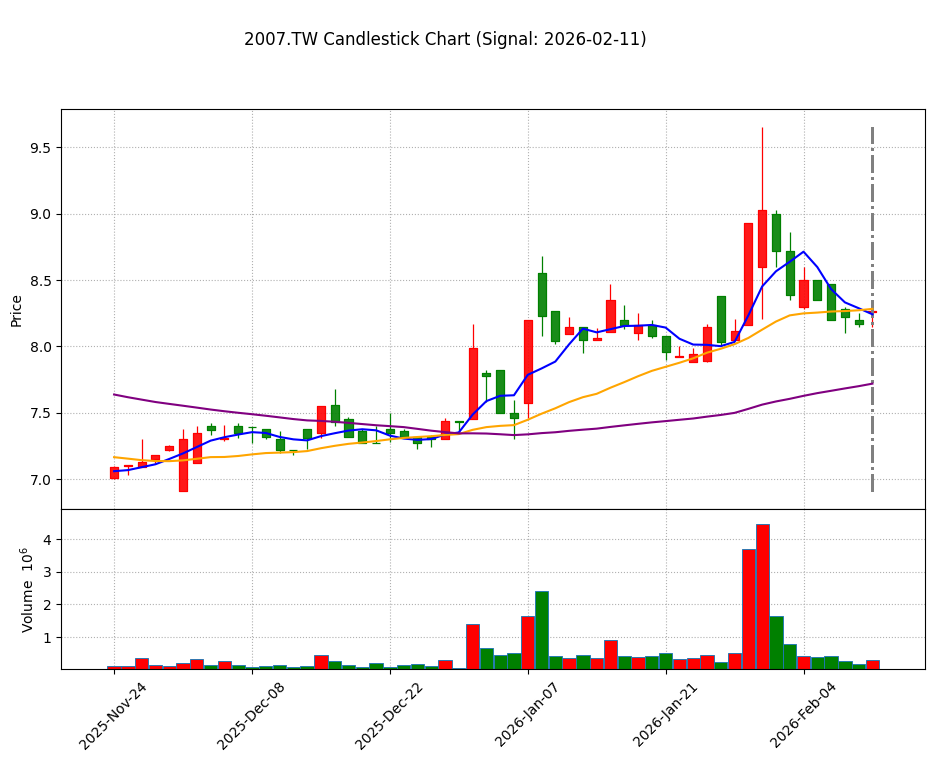

In [57]:
# 1. 自動抓取全台股近 2000 檔普通股名單
all_stocks = get_all_taiwan_stocks()

# 2. 將名單丟入您的過濾器
# (如果想先測試，可以切片 all_stocks[:50] 只跑前 50 檔看看速度)
filter_obj = TaiwanStockFilter(all_stocks)

# 3. 極速下載資料
filter_obj.fetch_data_with_cache()

# 4. 執行策略篩選
results = filter_obj.find_conforming_stocks()

print("\n🎉 === 掃描結果 ===")
if results:
    for res in results:
        print(f"標的: {res['Ticker']} | 收盤價: {res['Close']:.2f} | 拉回幅度: {res['Pullback_Pct']:.2f}% | 區間震幅: 非常平緩")

    # 畫出第一檔選出的股票線圖驗證
    first_match = results[0]['Ticker']
    filter_obj.plot_candlestick(first_match)
else:
    print("今天全市場沒有符合此嚴格型態的股票。")

## 畫出過濾後的股票 K 棒圖

📊 從暫存中讀取 2330.TW 資料...


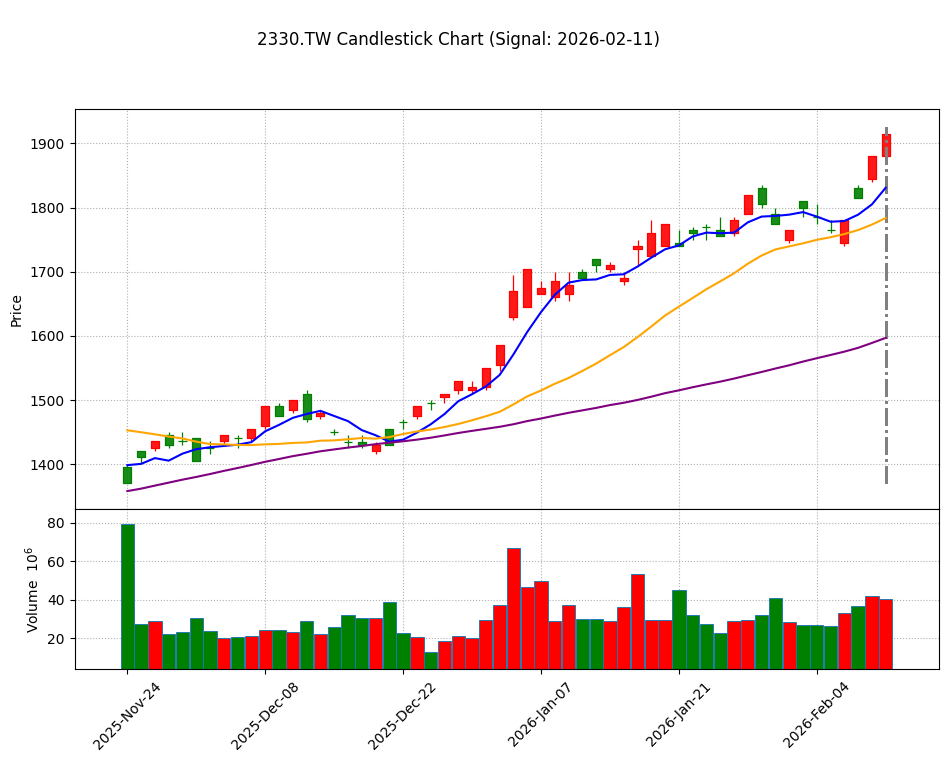

In [60]:
filter_obj.plot_candlestick('2330')

📊 從暫存中讀取 2007.TW 資料...


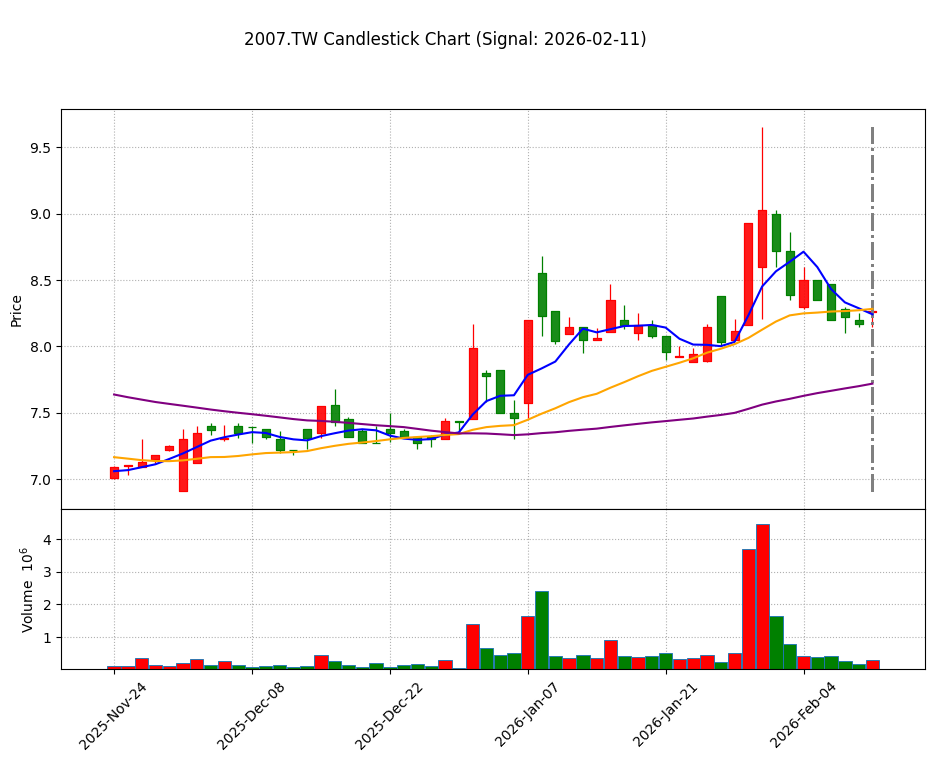

📊 從暫存中讀取 2462.TW 資料...


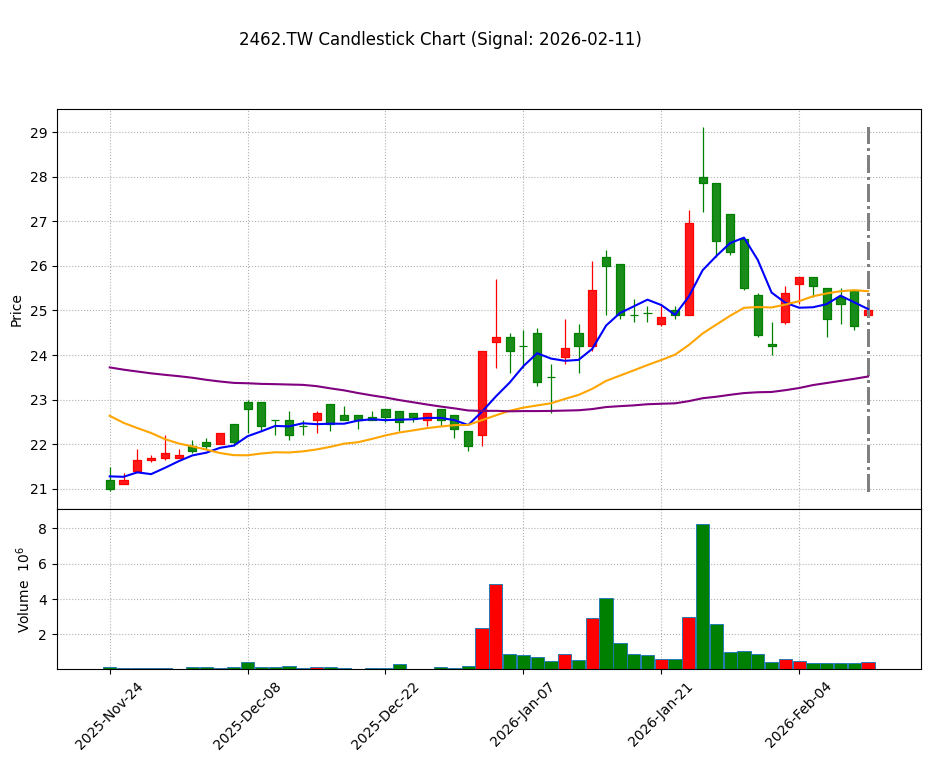

📊 從暫存中讀取 6776.TW 資料...


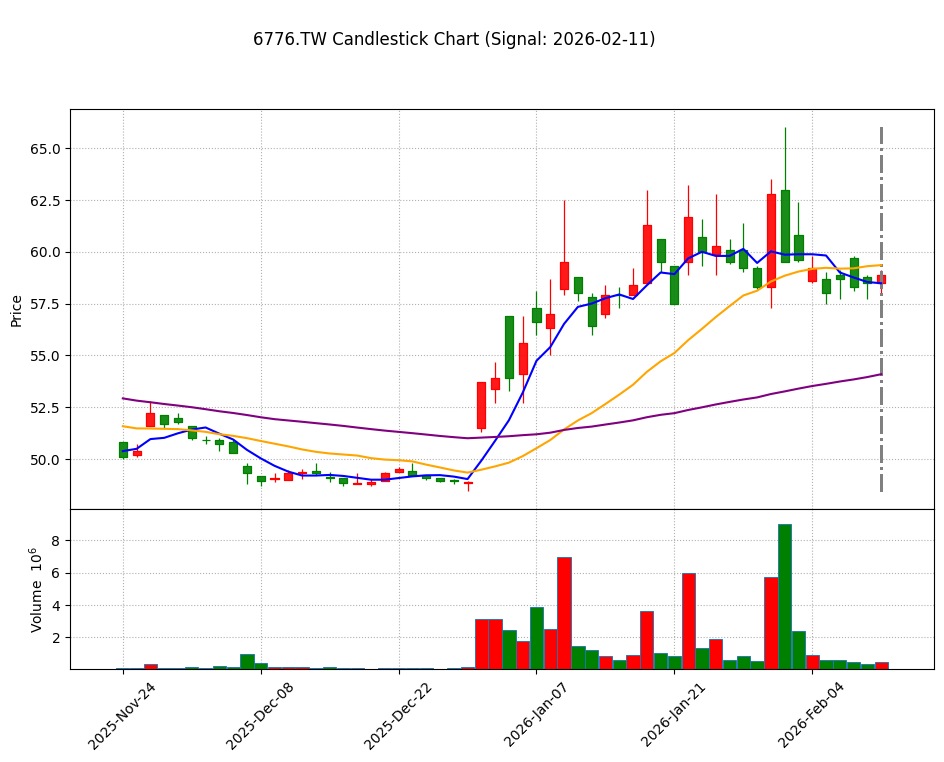

📊 從暫存中讀取 9136.TW 資料...


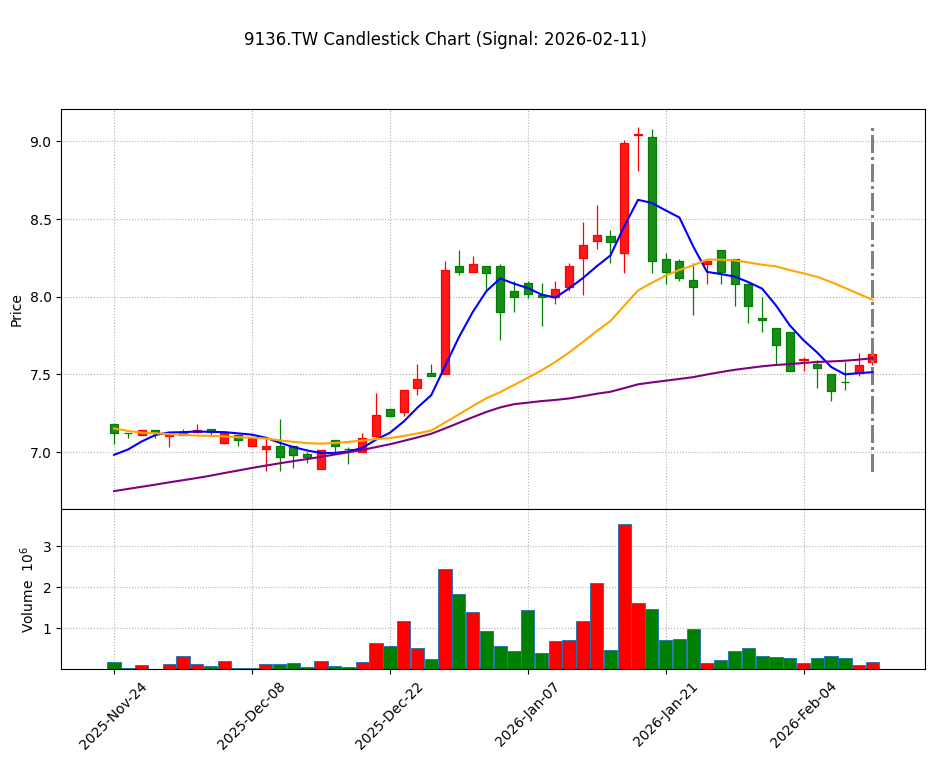

📊 從暫存中讀取 1101.TW 資料...


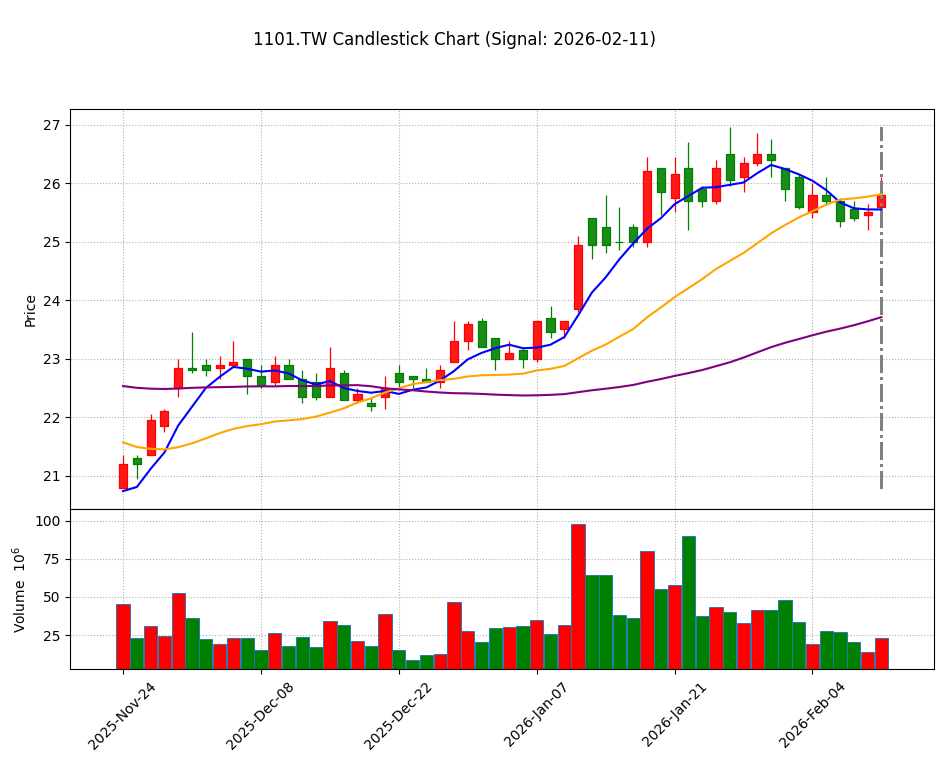

📊 從暫存中讀取 3501.TW 資料...


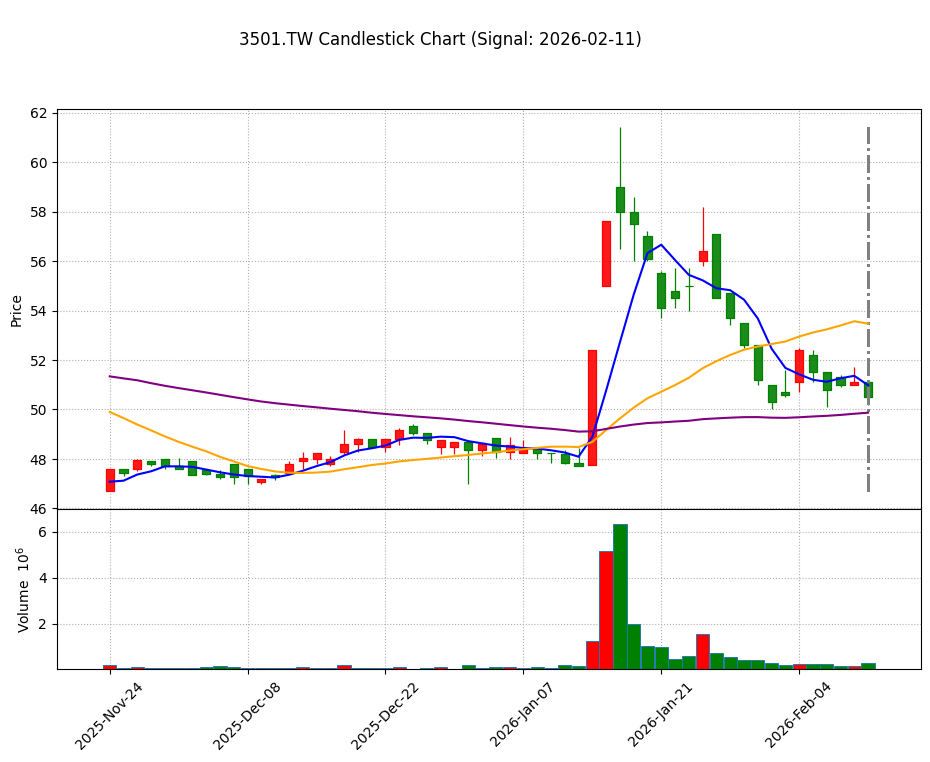

📊 從暫存中讀取 8249.TW 資料...


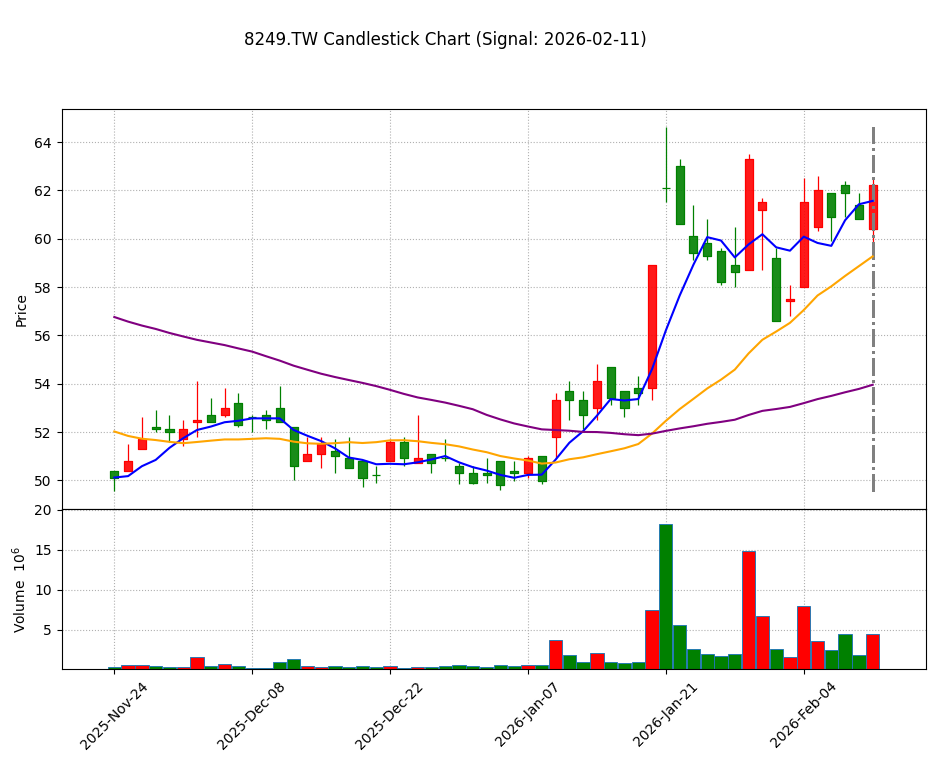

📊 從暫存中讀取 3023.TW 資料...


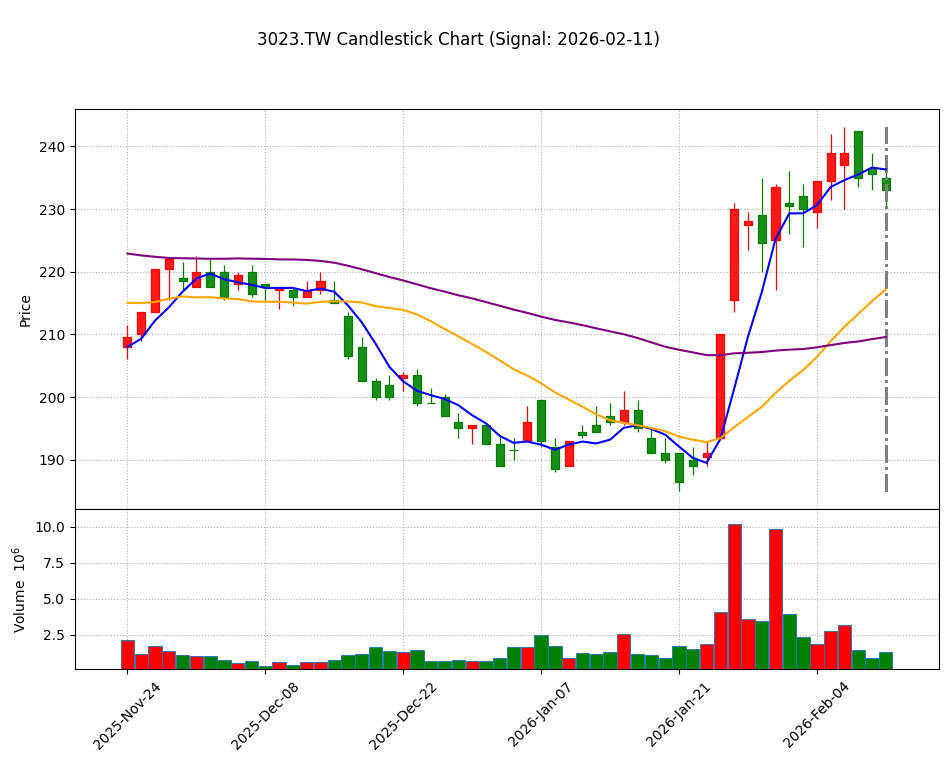

📊 從暫存中讀取 3338.TW 資料...


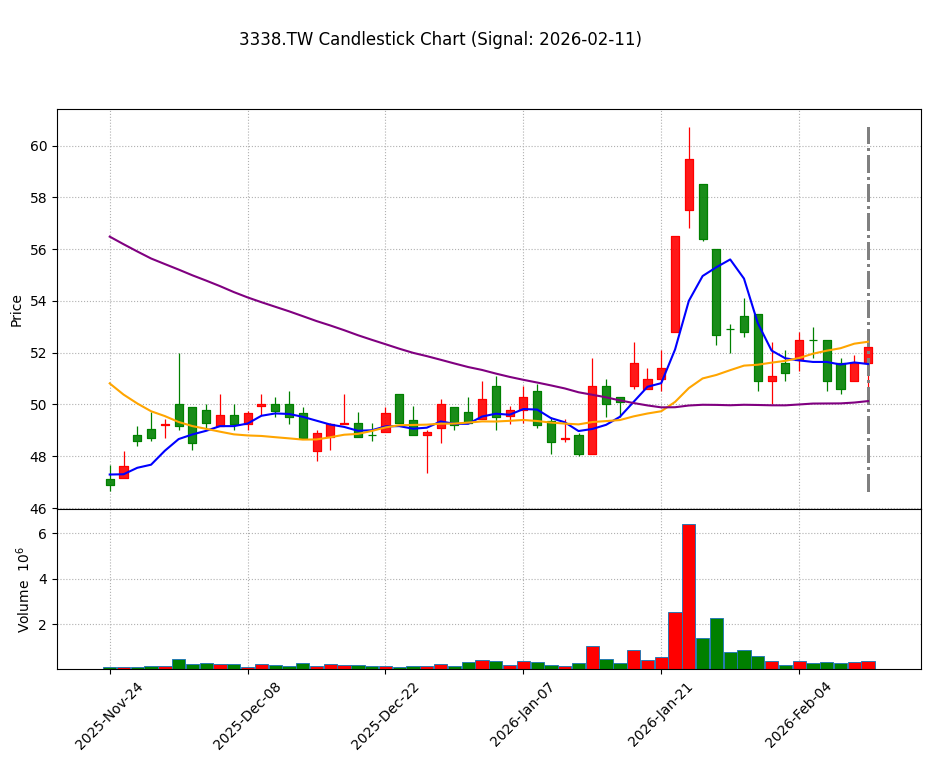

📊 從暫存中讀取 3591.TW 資料...


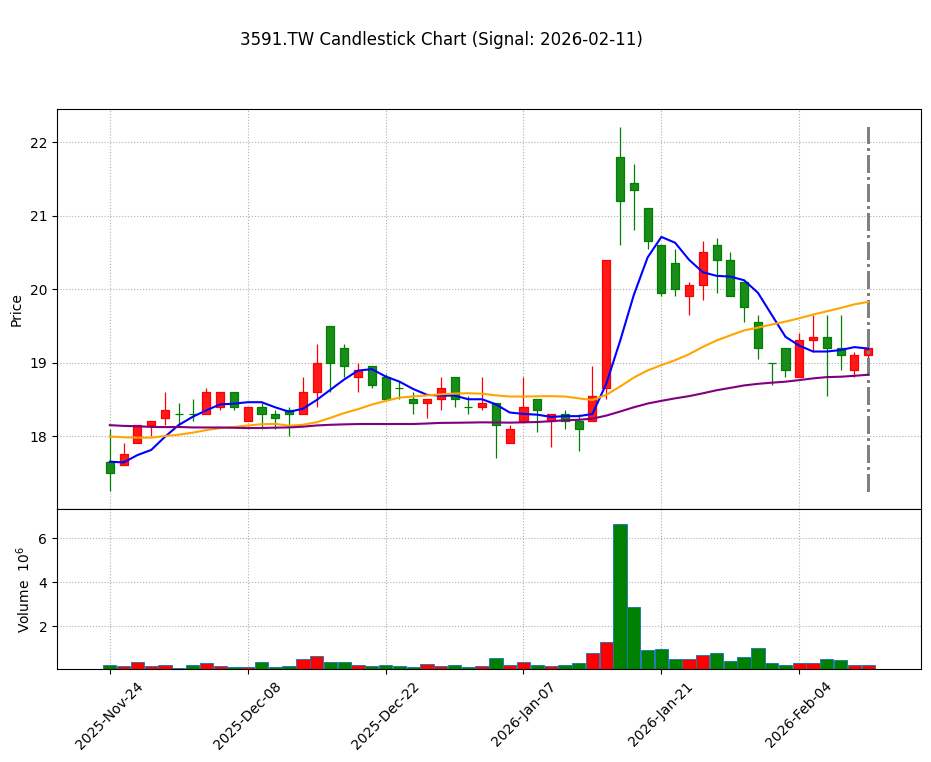

📊 從暫存中讀取 1713.TW 資料...


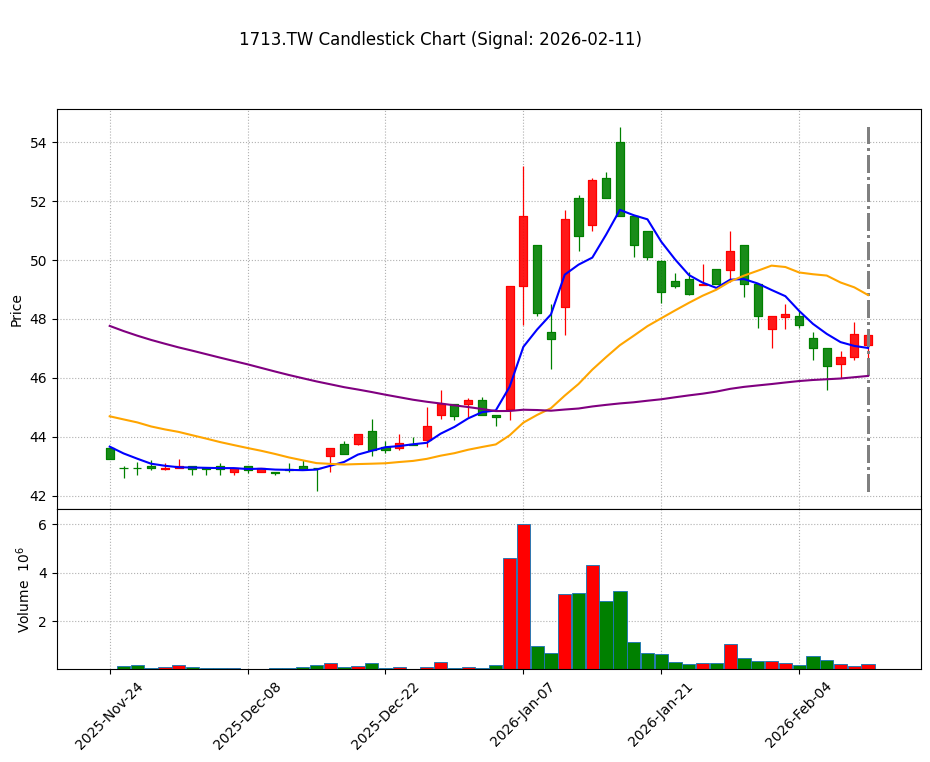

📊 從暫存中讀取 6605.TW 資料...


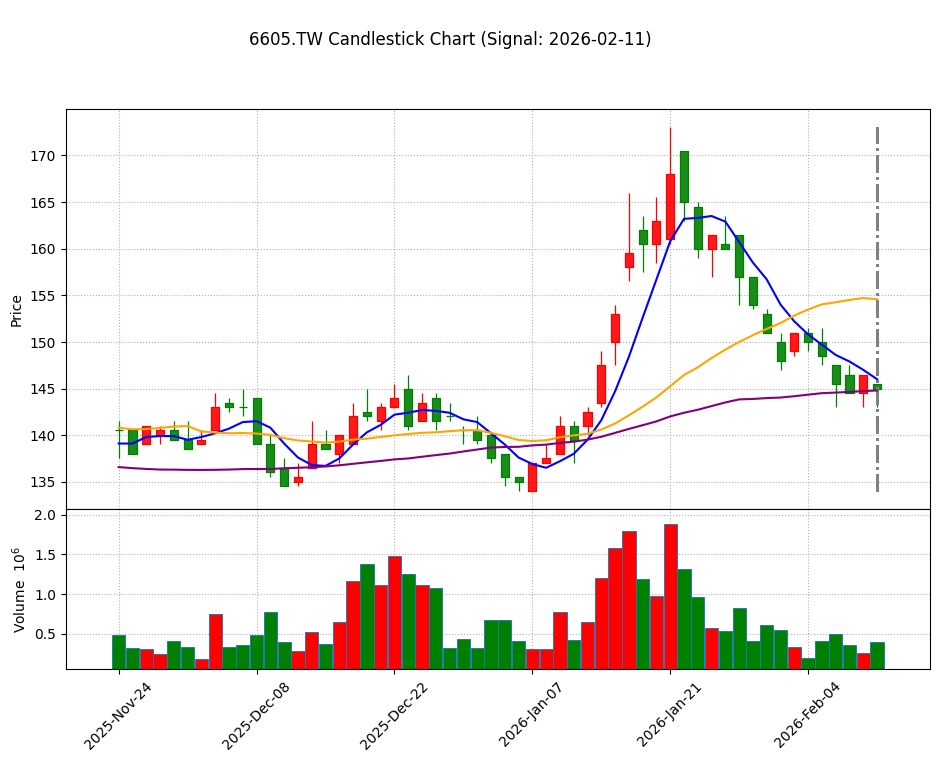

📊 從暫存中讀取 2606.TW 資料...


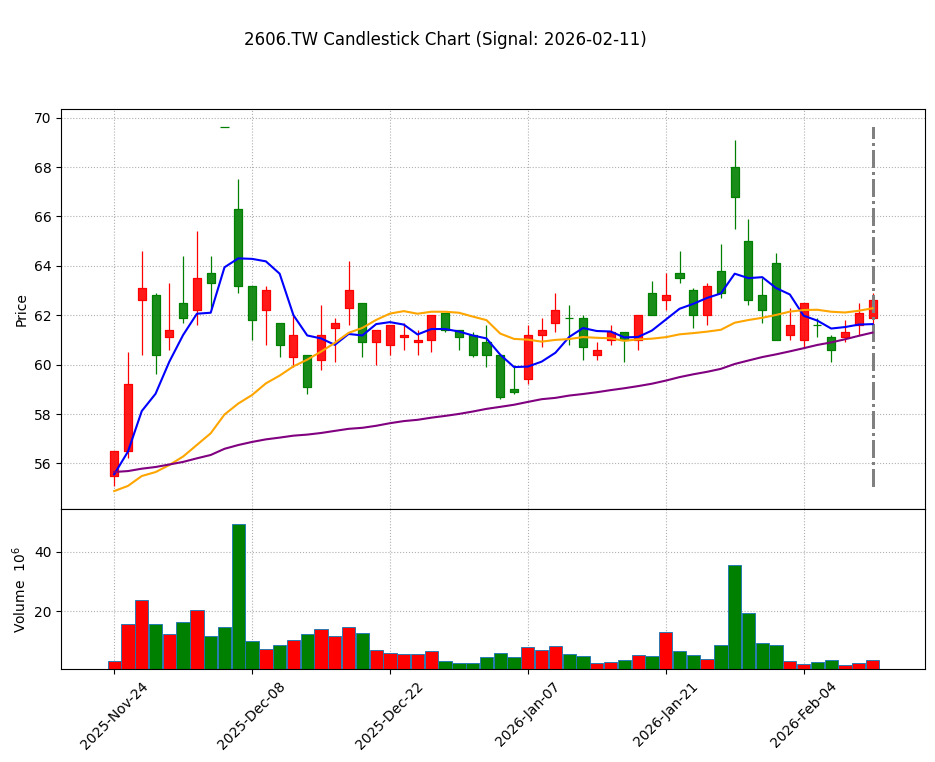

📊 從暫存中讀取 1477.TW 資料...


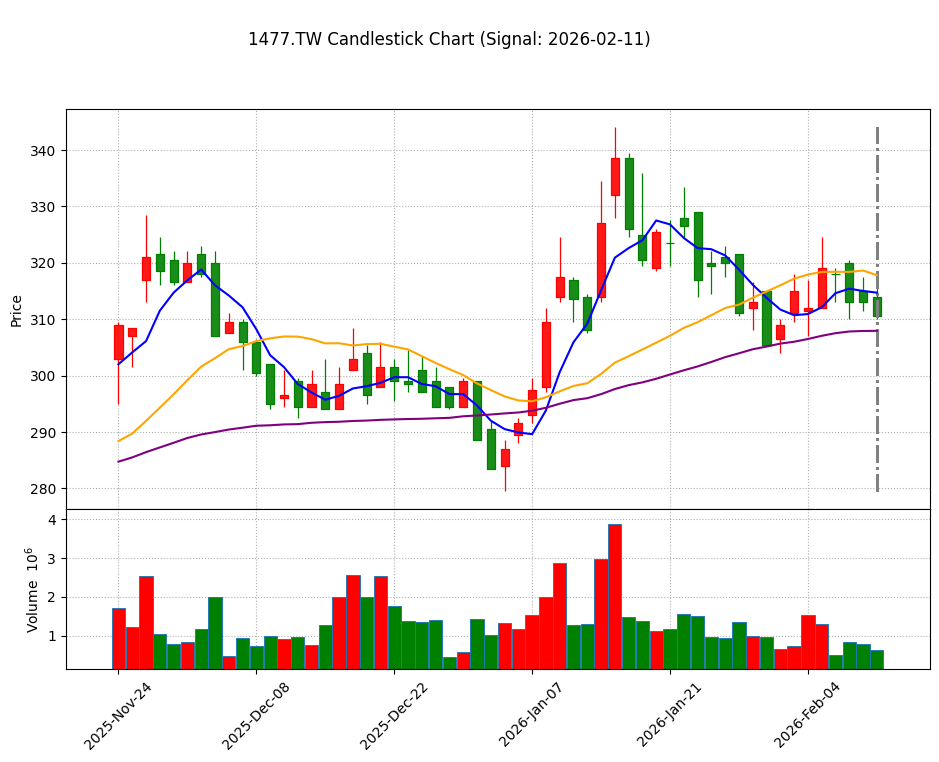

📊 從暫存中讀取 2002.TW 資料...


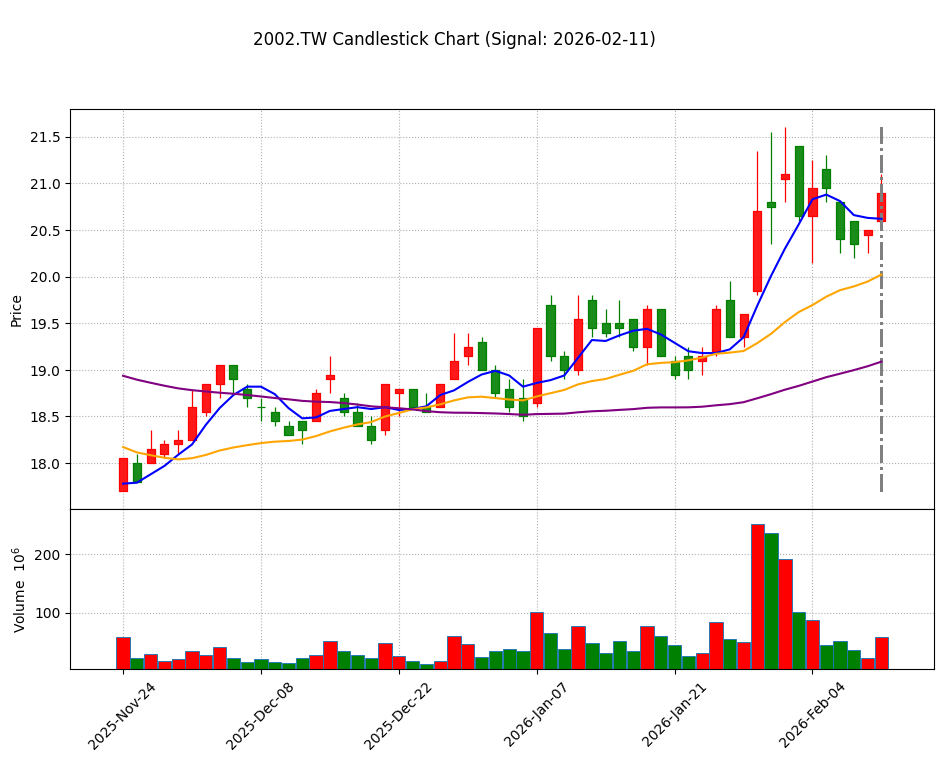

📊 從暫存中讀取 5907.TW 資料...


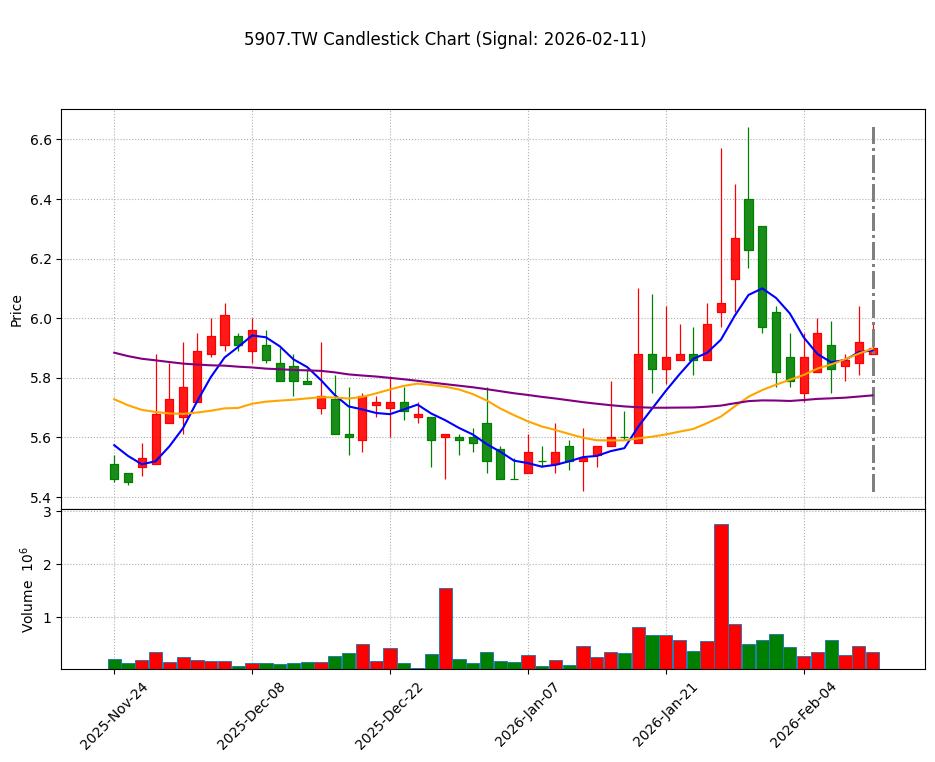

📊 從暫存中讀取 2637.TW 資料...


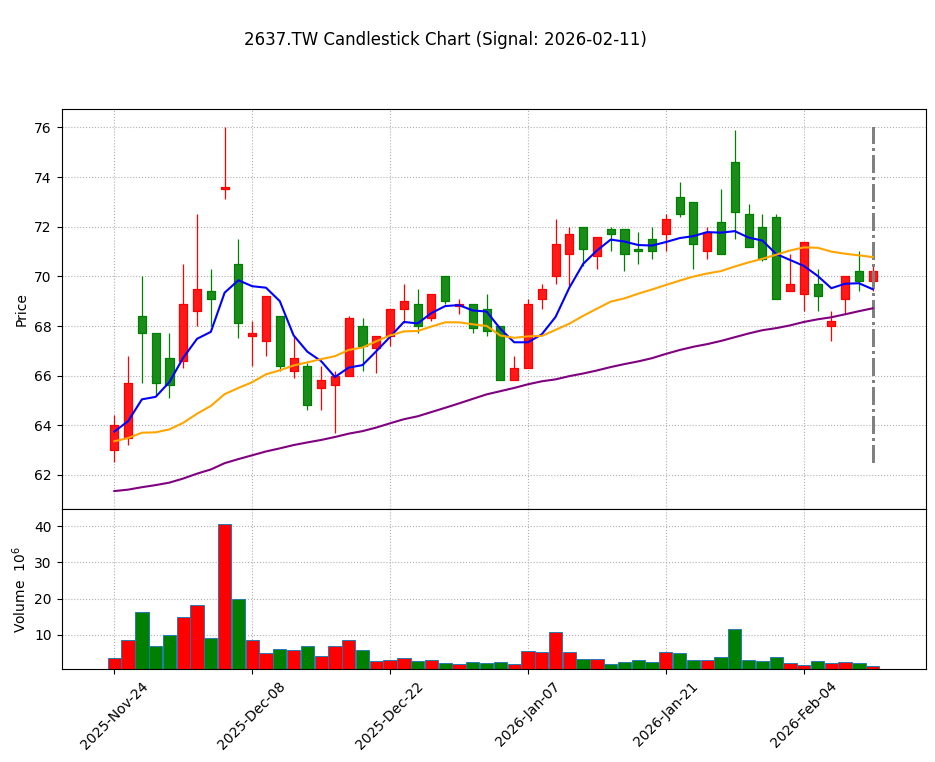

📊 從暫存中讀取 1527.TW 資料...


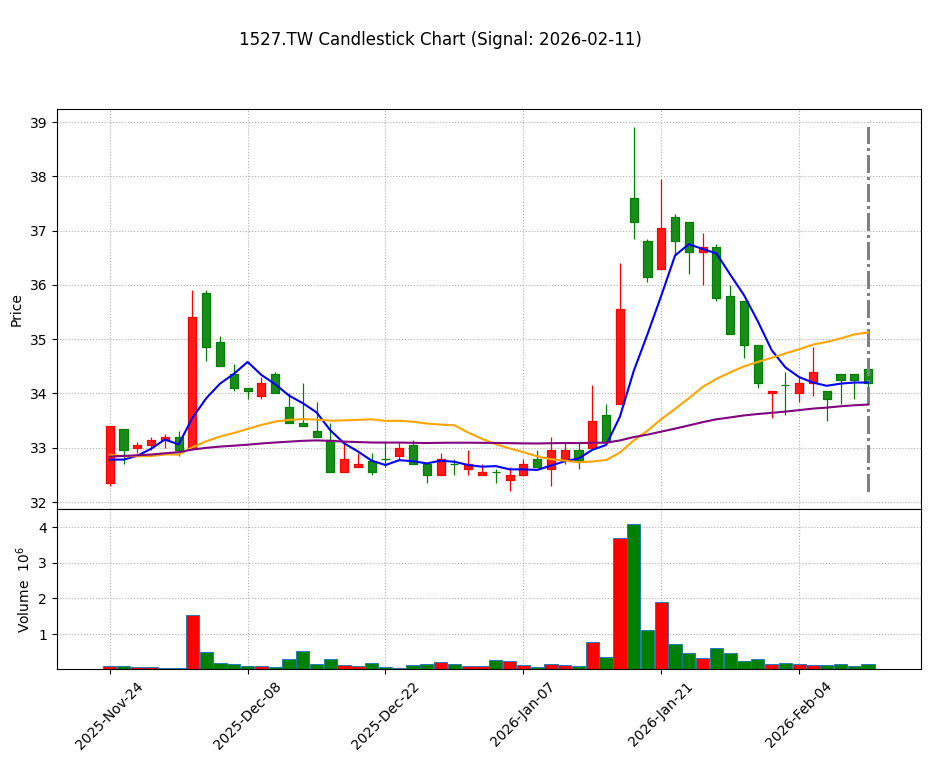

📊 從暫存中讀取 1215.TW 資料...


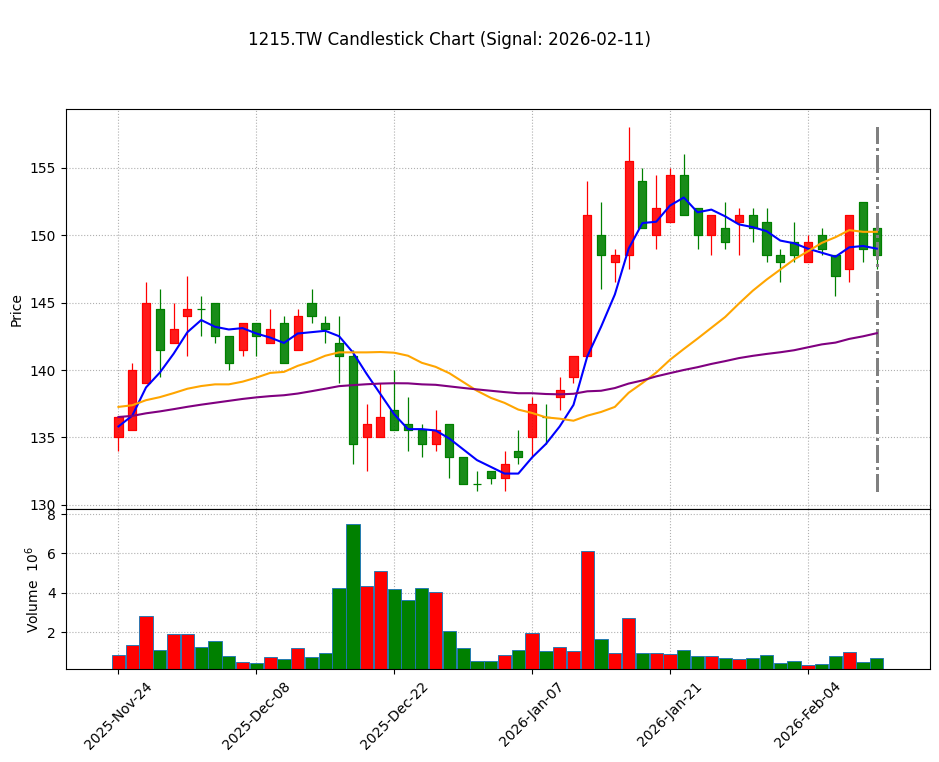

📊 從暫存中讀取 1611.TW 資料...


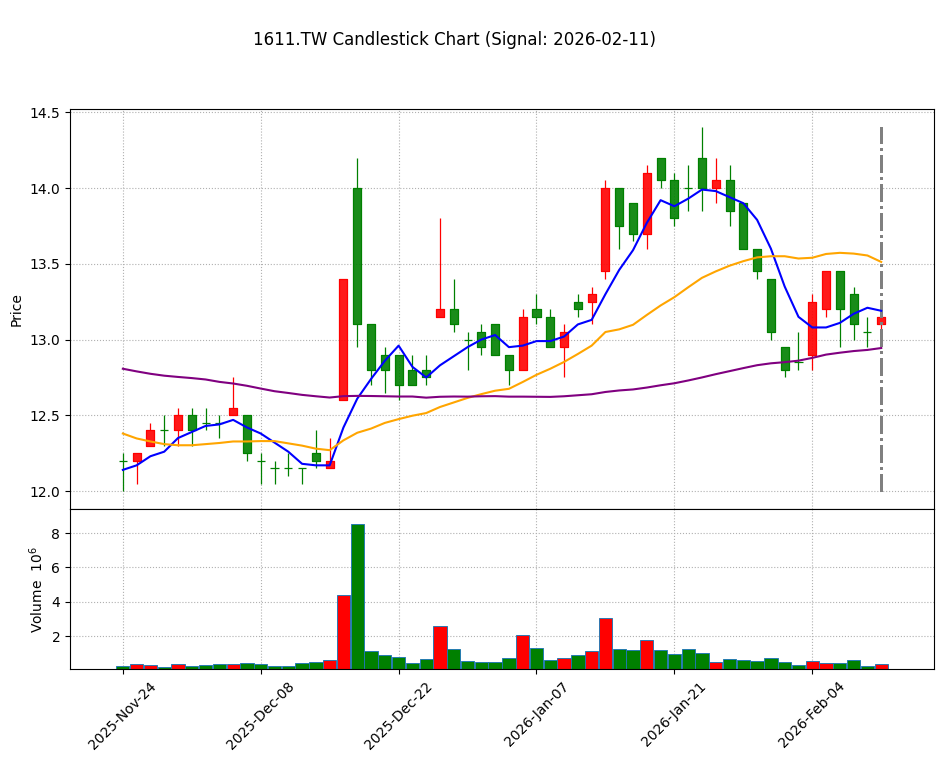

📊 從暫存中讀取 1310.TW 資料...


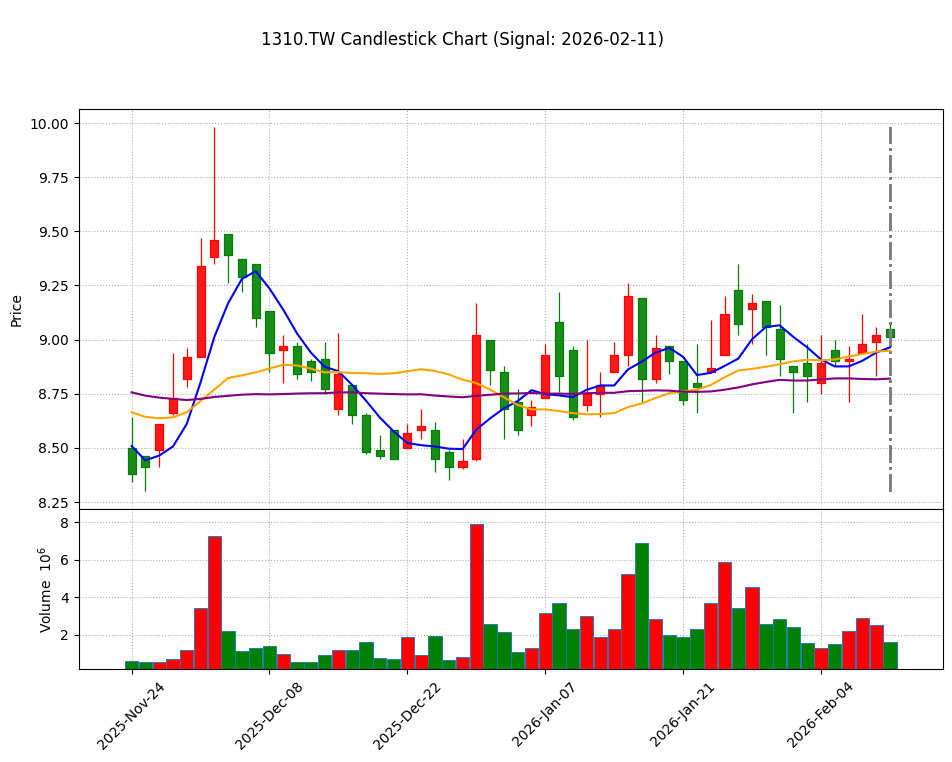

📊 從暫存中讀取 1582.TW 資料...


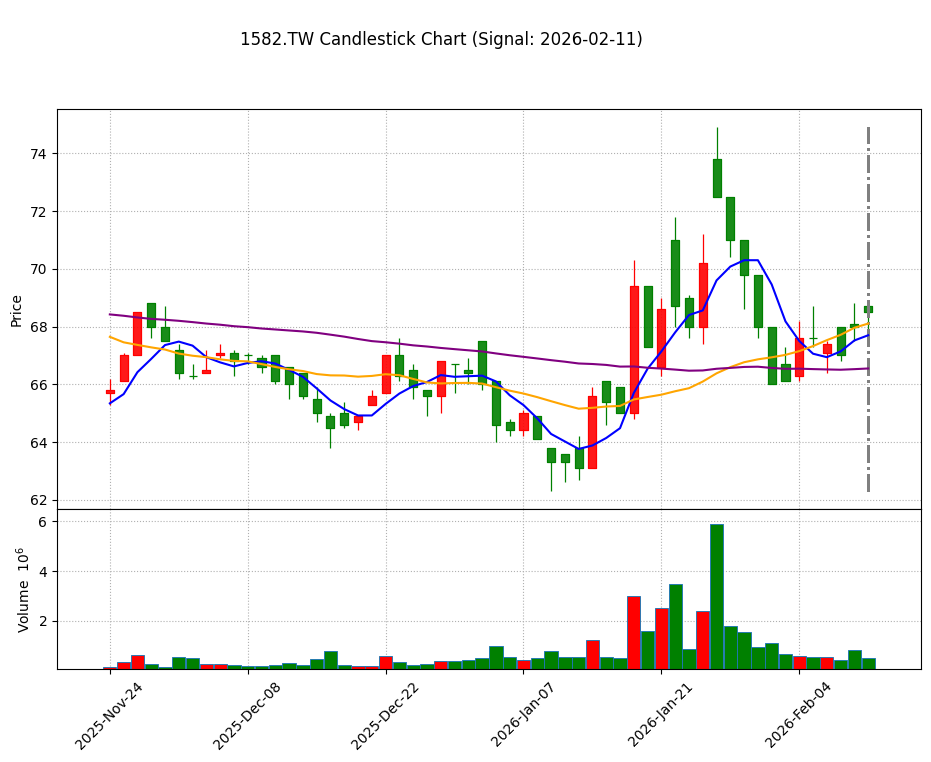

In [63]:
for res in results:
  filter_obj.plot_candlestick(res['Ticker'])